<a href="https://colab.research.google.com/github/shweta714/Car-Price_Prediction_Model/blob/main/Car_Price_Prediction_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/'))

['var', 'proc', 'tmp', 'mnt', 'sbin', 'lib64', 'media', 'home', 'root', 'sys', 'opt', 'run', 'lib', 'lib32', 'dev', 'usr', 'libx32', 'boot', 'srv', 'etc', 'bin', 'car_data.csv', 'kaggle', 'content', '.dockerenv', 'tools', 'datalab', 'python-apt', 'python-apt.tar.xz']


In [ ]:
df = pd.read_csv('/car_data.csv')

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4340
Number of columns: 8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 763


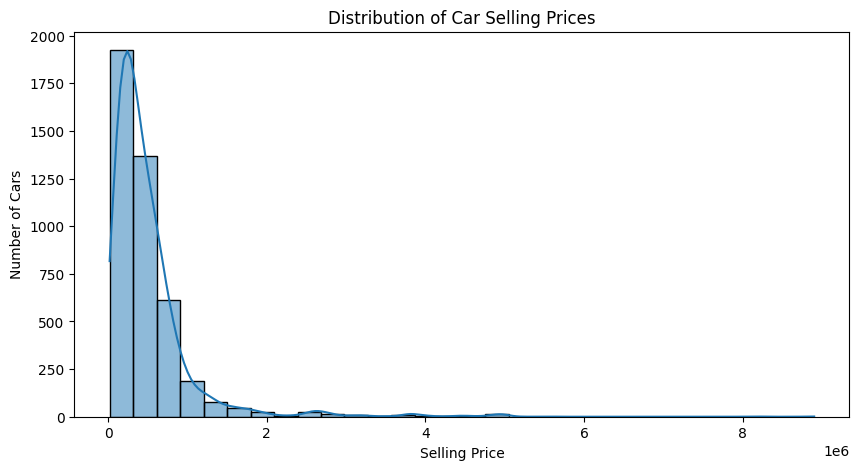

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['selling_price'], bins=30, kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

In [ ]:
from datetime import datetime

current_year = datetime.now().year

df['car_age'] = current_year - df['year']

df[['year', 'car_age', 'selling_price']].head()

,year,car_age,selling_price
0,2007,19,60000
1,2007,19,135000
2,2012,14,600000
3,2017,9,250000
4,2014,12,450000


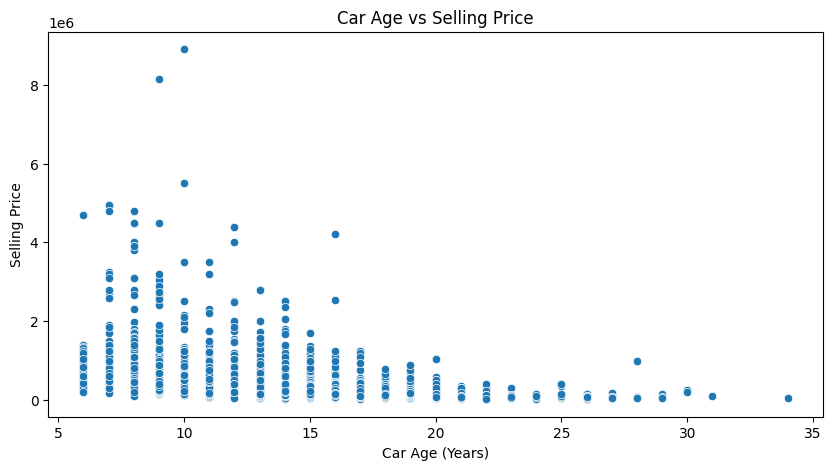

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price'
)

plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.show()

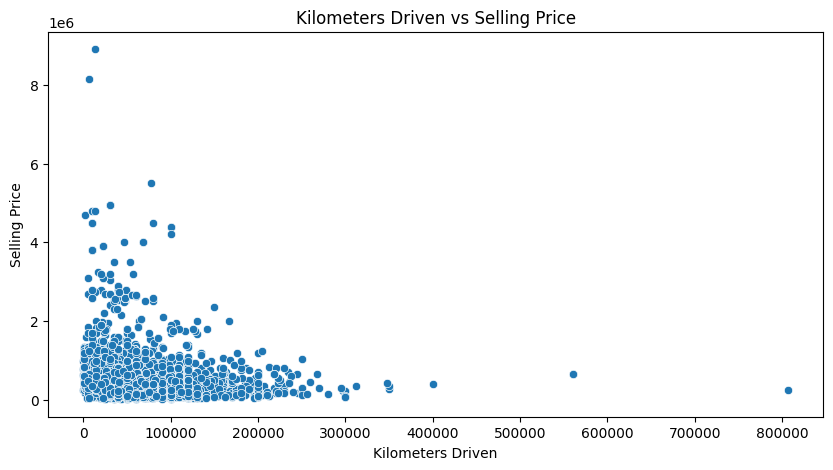

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price'
)

plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')

plt.show()

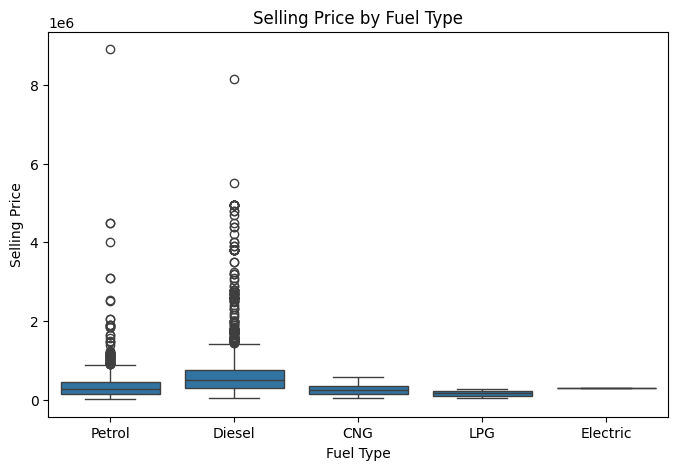

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

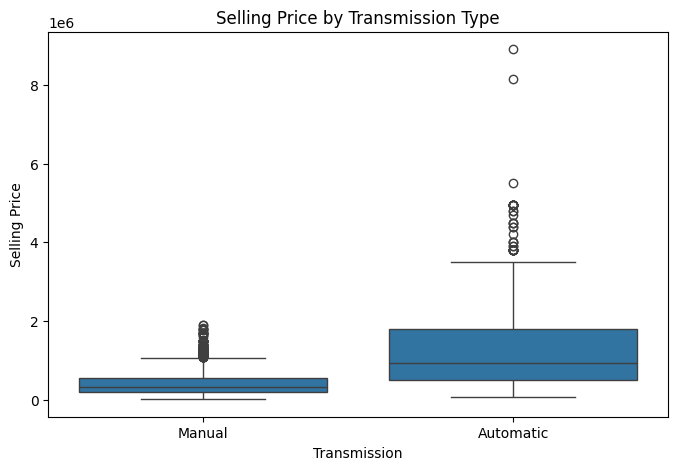

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='transmission',
    y='selling_price'
)

plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,year,selling_price,km_driven,car_age
year,1.000000,0.413922,-0.419688,-1.000000
selling_price,0.413922,1.000000,-0.192289,-0.413922
km_driven,-0.419688,-0.192289,1.000000,0.419688
car_age,-1.000000,-0.413922,0.419688,1.000000


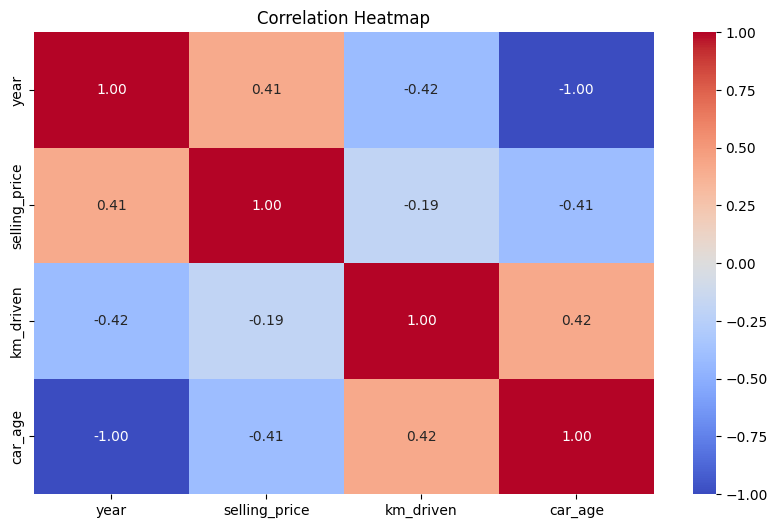

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

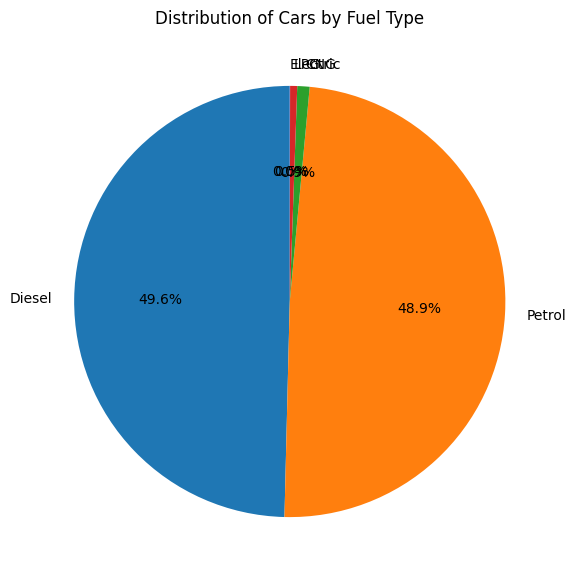

In [ ]:
plt.figure(figsize=(7, 7))

df['fuel'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Cars by Fuel Type')
plt.ylabel('')

plt.show()

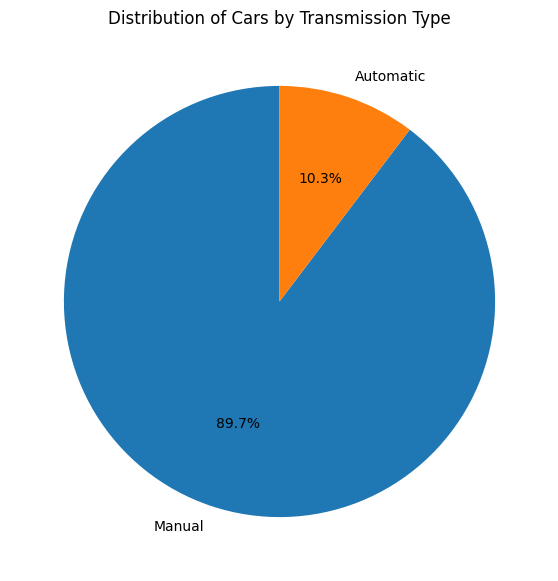

In [ ]:
plt.figure(figsize=(7, 7))

df['transmission'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Cars by Transmission Type')
plt.ylabel('')

plt.show()

In [ ]:
# Create a copy of the original dataset
data = df.copy()

# Check the dataset
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [ ]:
# Check number of unique car names
print("Unique car names:", data['name'].nunique())

Unique car names: 1491


In [ ]:
# Remove car name because it is a high-cardinality text feature
data = data.drop('name', axis=1)

data.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [ ]:
data[['year', 'car_age']].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [ ]:
# Remove original year column
data = data.drop('year', axis=1)

data.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,19
1,135000,50000,Petrol,Individual,Manual,First Owner,19
2,600000,100000,Diesel,Individual,Manual,First Owner,14
3,250000,46000,Petrol,Individual,Manual,First Owner,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [ ]:
# Separate features and target variable

X = data.drop('selling_price', axis=1)
y = data['selling_price']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   km_driven    fuel seller_type transmission         owner  car_age
0      70000  Petrol  Individual       Manual   First Owner       19
1      50000  Petrol  Individual       Manual   First Owner       19
2     100000  Diesel  Individual       Manual   First Owner       14
3      46000  Petrol  Individual       Manual   First Owner        9
4     141000  Diesel  Individual       Manual  Second Owner       12

Target:
0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64


In [ ]:
# Display data types of features
X.dtypes

,0
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
car_age,int64


In [ ]:
# Convert categorical columns into numerical values

X_encoded = pd.get_dummies(
    X,
    columns=['fuel', 'seller_type', 'transmission', 'owner'],
    drop_first=True,
    dtype=int
)

# Check the transformed data
X_encoded.head()

,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,70000,19,0,0,0,1,1,0,1,0,0,0,0
1,50000,19,0,0,0,1,1,0,1,0,0,0,0
2,100000,14,1,0,0,0,1,0,1,0,0,0,0
3,46000,9,0,0,0,1,1,0,1,0,0,0,0
4,141000,12,1,0,0,0,1,0,1,0,1,0,0


In [ ]:
print("Original features:", X.shape)
print("Encoded features:", X_encoded.shape)

print("\nFinal Features:")
print(X_encoded.columns.tolist())

Original features: (4340, 6)
Encoded features: (4340, 10)

Final Features:
['km_driven', 'owner', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3472, 10)
Testing data: (868, 10)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3472, 13)
Testing data: (868, 13)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# Make predictions on test data
y_pred_lr = lr_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_lr[:10])

First 10 predictions:
[ 429791.44395393  504490.85855368   60211.1711833   475380.44208611
 1519809.14934826  226071.99825232  444068.63087629  255872.36232029
  648609.79806472  308855.00051455]


In [ ]:
# Calculate evaluation metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 221706.36930930085
RMSE: 426786.6899872593
R²  : 0.4031303601432117


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_dt[:10])

First 10 predictions:
[ 150000.          280000.          120000.          450000.
 3200000.          280000.          530000.           92800.
  449666.66666667  249000.        ]


In [ ]:
# Evaluate Decision Tree

mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
--------------------
MAE : 178846.28354007102
RMSE: 434798.35800813214
R²  : 0.3805110761203422


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_rf[:10])

First 10 predictions:
[ 152268.80952381  489012.5         123585.          492349.99
 1847068.425       208058.55595238  434710.           93380.
  544676.86320437  246600.        ]


In [ ]:
# Evaluate Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 169692.38493433272
RMSE: 391792.28128665366
R²  : 0.4969982377862653


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf
    ],

    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],

    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,221706.369309,426786.689987,0.403130
1,Decision Tree,178846.283540,434798.358008,0.380511
2,Random Forest,169692.384934,391792.281287,0.496998


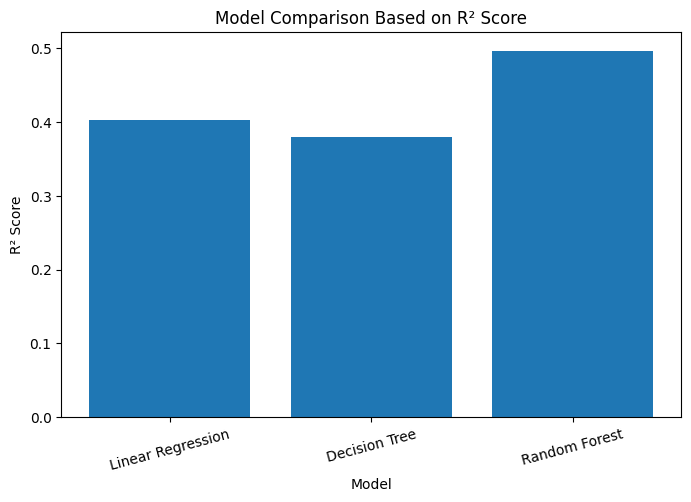

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['R2 Score']
)

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison Based on R² Score')

plt.xticks(rotation=15)

plt.show()

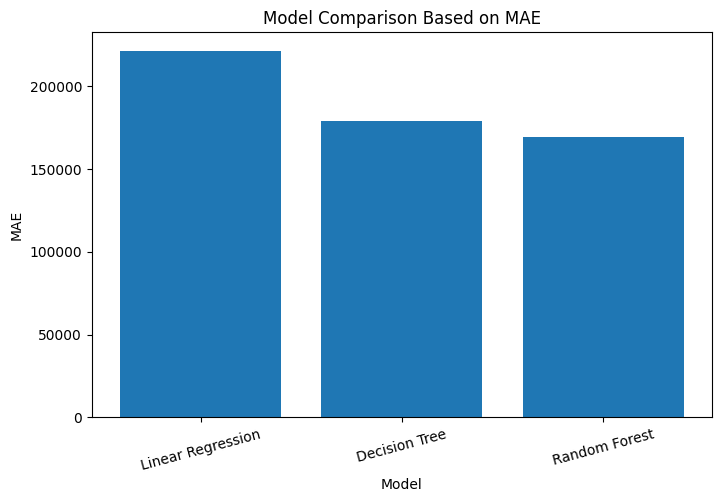

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['MAE']
)

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Model Comparison Based on MAE')

plt.xticks(rotation=15)

plt.show()

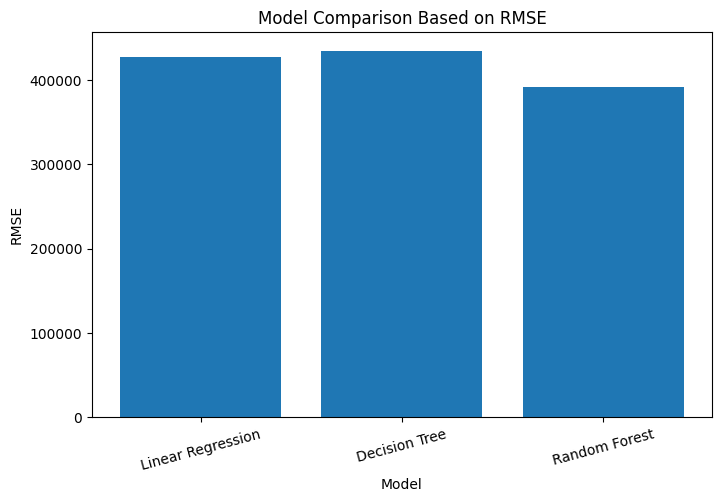

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['RMSE']
)

plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Model Comparison Based on RMSE')

plt.xticks(rotation=15)

plt.show()

In [ ]:
best_model_name = results.loc[
    results['R2 Score'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Random Forest


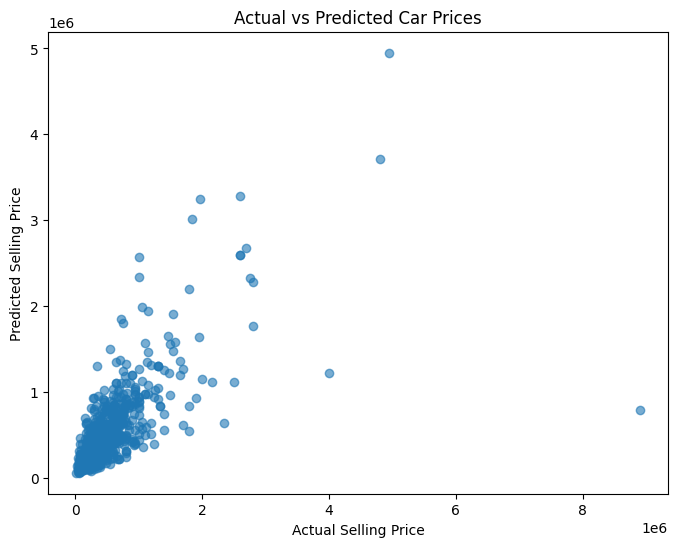

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

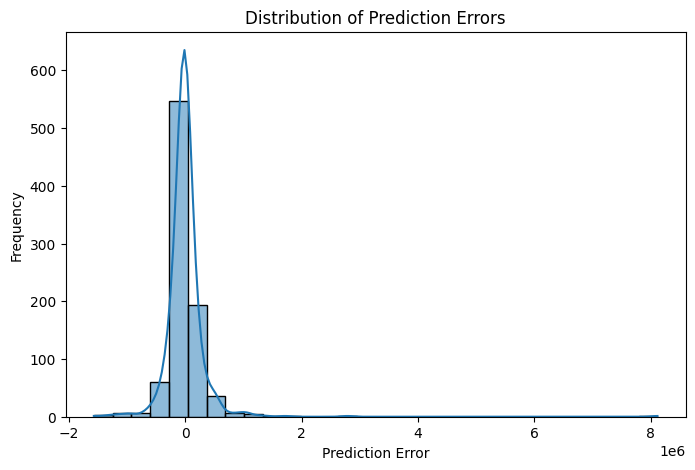

In [ ]:
errors = y_test - y_pred_rf

plt.figure(figsize=(8, 5))

sns.histplot(errors, bins=30, kde=True)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [ ]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
8,transmission_Manual,0.300561
0,km_driven,0.287236
1,car_age,0.199001
2,fuel_Diesel,0.118871
6,seller_type_Individual,0.048073
5,fuel_Petrol,0.020197
10,owner_Second Owner,0.016552
7,seller_type_Trustmark Dealer,0.005194
12,owner_Third Owner,0.003192
9,owner_Fourth & Above Owner,0.000559


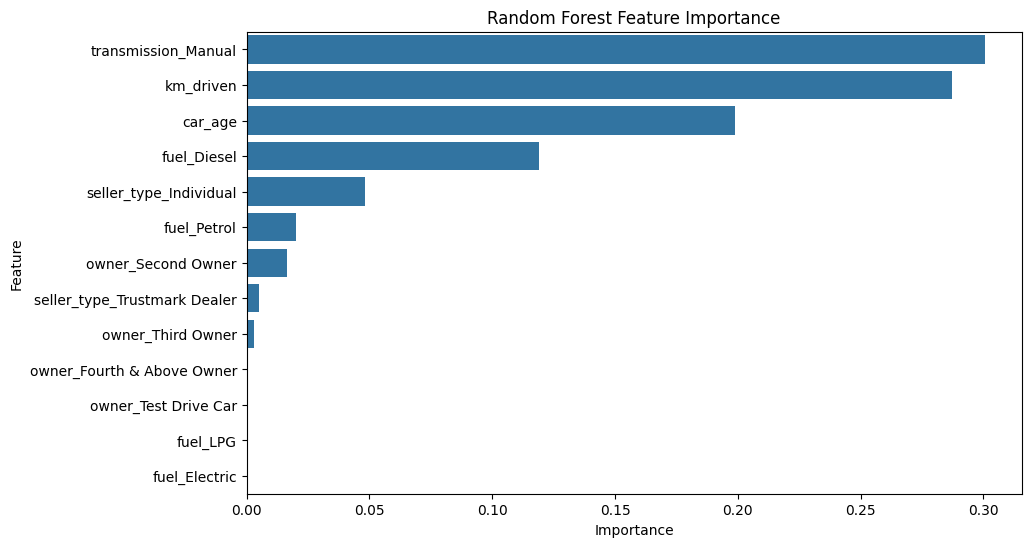

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation R²:
0.6801742229768017


In [ ]:
grid_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [ ]:
# Get the best Random Forest model

best_rf_model = grid_search.best_estimator_

print("Optimized Random Forest model ready!")

Optimized Random Forest model ready!


In [ ]:
# Predictions using optimized Random Forest

y_pred_best = best_rf_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_best[:10])

First 10 predictions:
[ 198342.70163294  479387.96548741  146983.04853665  483706.45327396
 1736496.2038576   195494.72656897  469202.86996596   96696.32871865
  545873.15737179  256203.20734181]


In [ ]:
# Evaluate the optimized Random Forest

final_mae = mean_absolute_error(y_test, y_pred_best)

final_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

final_r2 = r2_score(y_test, y_pred_best)

print("Optimized Random Forest Results")
print("--------------------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Optimized Random Forest Results
--------------------------------
MAE : 168801.237611724
RMSE: 393333.9063915204
R²  : 0.49303202516136513


In [ ]:
# Store the feature names used during training

feature_names = X_encoded.columns.tolist()

print("Features used by the model:")
print(feature_names)

Features used by the model:
['km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


In [ ]:
# Get car details from the user

present_price = float(input("Enter Present Price (in Lakhs): "))
km_driven = float(input("Enter Kilometers Driven: "))
fuel = input("Enter Fuel Type (Petrol/Diesel/CNG): ")
seller_type = input("Enter Seller Type (Dealer/Individual): ")
transmission = input("Enter Transmission (Manual/Automatic): ")
owner = input("Enter Owner (First Owner/Second Owner/Third Owner/Fourth & Above Owner/Test Drive Car): ")
car_age = int(input("Enter Car Age (in years): "))

Enter Present Price (in Lakhs): 8.5
Enter Kilometers Driven: 45000
Enter Fuel Type (Petrol/Diesel/CNG): Diesel
Enter Seller Type (Dealer/Individual): Dealer
Enter Transmission (Manual/Automatic): Manual
Enter Owner (First Owner/Second Owner/Third Owner/Fourth & Above Owner/Test Drive Car): First Owner
Enter Car Age (in years): 5


In [ ]:
# Create DataFrame from user input

user_data = pd.DataFrame({
    'present_price': [present_price],
    'km_driven': [km_driven],
    'fuel': [fuel],
    'seller_type': [seller_type],
    'transmission': [transmission],
    'owner': [owner],
    'car_age': [car_age]
})

user_data

,present_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,8.5,45000.0,Diesel,Dealer,Manual,First Owner,5


In [ ]:
# Encode categorical variables

user_encoded = pd.get_dummies(
    user_data,
    columns=['fuel', 'seller_type', 'transmission', 'owner'],
    drop_first=True,
    dtype=int
)

user_encoded

,present_price,km_driven,car_age
0,8.5,45000.0,5


In [ ]:
# Match user input with training features

user_encoded = user_encoded.reindex(
    columns=feature_names,
    fill_value=0
)

user_encoded

,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,45000.0,5,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Predict car selling price

predicted_price = best_rf_model.predict(user_encoded)[0]

print("=" * 45)
print("        🚗 CAR PRICE PREDICTION")
print("=" * 45)
print(f"Predicted Selling Price: ₹{predicted_price:.2f} Lakhs")
print("=" * 45)

        🚗 CAR PRICE PREDICTION
Predicted Selling Price: ₹1191774.13 Lakhs
